In [1]:
from typing import TypedDict, Annotated
from dotenv import load_dotenv

from langgraph.graph import StateGraph, END, add_messages
from langchain_core.messages import HumanMessage
from langchain_groq import ChatGroq

load_dotenv()

# -------------------------
# LLM
# -------------------------
llm = ChatGroq(model="llama-3.1-8b-instant")

# -------------------------
# State
# -------------------------
class State(TypedDict):
    messages: Annotated[list, add_messages]
    review_decision: str | None

# -------------------------
# Nodes
# -------------------------
def generate_post(state: State):
    """Generate LinkedIn post"""
    ai_message = llm.invoke(state["messages"])
    return {"messages": [ai_message]}


def review_node(state: State):
    """Human reviews the post"""
    post_content = state["messages"][-1].content

    print("\n📢 Generated LinkedIn Post:\n")
    print(post_content)
    print("\n")

    decision = input("Post to LinkedIn? (yes/no): ").strip().lower()
    return {"review_decision": decision}


def collect_feedback(state: State):
    """Collect human feedback"""
    feedback = input("How can I improve this post? ")
    return {
        "messages": [HumanMessage(content=feedback)],
        "review_decision": None
    }


def post_node(state: State):
    """Final post action"""
    final_post = state["messages"][-1].content

    print("\n✅ Final LinkedIn Post:\n")
    print(final_post)
    print("\n🚀 Post approved and published!")
    return {}

# -------------------------
# Router
# -------------------------
def review_router(state: State):
    if state["review_decision"] == "yes":
        return "post"
    return "collect_feedback"

# -------------------------
# Graph
# -------------------------
graph = StateGraph(State)

graph.add_node("generate_post", generate_post)
graph.add_node("review", review_node)
graph.add_node("collect_feedback", collect_feedback)
graph.add_node("post", post_node)

graph.set_entry_point("generate_post")

graph.add_edge("generate_post", "review")

graph.add_conditional_edges(
    "review",
    review_router,
    {
        "post": "post",
        "collect_feedback": "collect_feedback"
    }
)

graph.add_edge("collect_feedback", "generate_post")
graph.add_edge("post", END)

app = graph.compile()




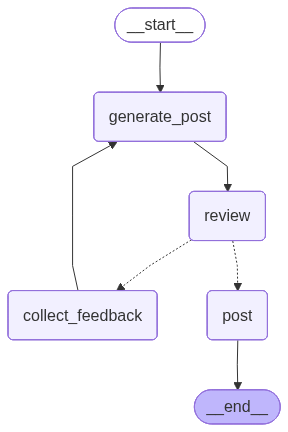

In [5]:
from IPython.display import display,Image
# Call the method to generate PNG bytes
png_bytes = app.get_graph().draw_mermaid_png()

# Pass bytes directly
display(Image(data=png_bytes))

In [7]:
# -------------------------
# Run
# -------------------------
app.invoke({
    "messages": [
        HumanMessage(
            content="Write a LinkedIn post on AI Agents transforming content creation"
        )
    ],
    "review_decision": None
})


📢 Generated LinkedIn Post:

**The Future of Content Creation is Here: How AI Agents are Revolutionizing the Industry**

As we continue to navigate the ever-evolving landscape of digital content, it's time to talk about the game-changers that are transforming the way we create, consume, and interact with content. Artificial Intelligence (AI) agents, specifically designed to assist with content creation, are emerging as a powerful force that's poised to revolutionize the industry.

**What are AI Agents?**

AI agents are intelligent software systems that can analyze, generate, and optimize content based on user preferences, data insights, and performance metrics. These agents are trained on vast amounts of data, allowing them to learn patterns, trends, and best practices in content creation.

**How are AI Agents transforming content creation?**

1. **Personalization**: AI agents can create tailored content that resonates with specific audiences, taking into account their interests, behav

{'messages': [HumanMessage(content='Write a LinkedIn post on AI Agents transforming content creation', additional_kwargs={}, response_metadata={}, id='31027e15-dbf0-4a28-9306-ba5127d5449f'),
  AIMessage(content="**The Future of Content Creation is Here: How AI Agents are Revolutionizing the Industry**\n\nAs we continue to navigate the ever-evolving landscape of digital content, it's time to talk about the game-changers that are transforming the way we create, consume, and interact with content. Artificial Intelligence (AI) agents, specifically designed to assist with content creation, are emerging as a powerful force that's poised to revolutionize the industry.\n\n**What are AI Agents?**\n\nAI agents are intelligent software systems that can analyze, generate, and optimize content based on user preferences, data insights, and performance metrics. These agents are trained on vast amounts of data, allowing them to learn patterns, trends, and best practices in content creation.\n\n**How a